<a href="https://colab.research.google.com/github/sebassanchez5680-tech/Prueba/blob/main/Sesion12_Evaluacion_Analisis_Descriptivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación — Análisis Descriptivo de Datos

**Entrega individual**

- **Nombre:** Sebastian Miguel Sanchez Salas
- **Matrícula:** 271757

Esta evaluación aplica los cuatro bloques de la Sesión 12 (tendencia central, dispersión, forma, visualización) a un dataset que no se trabajó en clase: **NYC Airbnb 2019**, específicamente la columna `price`.

| | |
|---|---|
| **Tiempo estimado** | 45-55 min |
| **Entrega** | Notebook completo (.ipynb) con todas las celdas ejecutadas, subido a Moodle |
| **Puntaje total** | 100 puntos (ver rúbrica al final) |

Cada actividad tiene su propia pregunta de conclusión — esas respuestas se califican como parte de la actividad correspondiente, no concentradas en la reflexión final. Comenta tu código donde tomes una decisión (por ejemplo, cuántos bins usar en un histograma, o qué columna comparar) — el comentario también forma parte del puntaje.

## Preparación

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv'
df = pd.read_csv(url)
df[['name', 'neighbourhood_group', 'room_type', 'price']].head()

,name,neighbourhood_group,room_type,price
0,Clean & quiet apt home by the park,Brooklyn,Private room,149
1,Skylit Midtown Castle,Manhattan,Entire home/apt,225
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Private room,150
3,Cozy Entire Floor of Brownstone,Brooklyn,Entire home/apt,89
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,Entire home/apt,80


---
## Actividad 1 — Tendencia central (20 pts)

In [40]:
# 1.1 — Calcula la media, mediana y moda de la columna 'price'.
media = df['price'].mean() #calculamos la media
mediana = df['price'].median() #calculamos la mediana
moda = df['price'].mode() #calculamos la moda

print("Media :", media)
print("Mediana :", mediana)
print("Moda :", moda)



Media : 152.7206871868289
Mediana : 106.0
Moda : 0    100
Name: price, dtype: int64


**1.2 — Conclusión (responde aquí en Markdown):**

¿La media y la mediana de `price` se parecen o divergen mucho? Con base en lo que viste en clase sobre `Income`, ¿qué te sugiere esa divergencia (o esa similitud) sobre la presencia de valores extremos en esta columna?

_Tu respuesta:_

La media y mediana de price divergen por bastante cantidad, mientras que la media son 152.72 la mediana es de 106 una diferencia de casi $47
La diferencia puede ser debido a que dentro de price existen datos atipicos extremos muy grandes que inflan las cantidades de la media


---
## Actividad 2 — Dispersión (20 pts)

In [41]:
# 2.1 — Calcula el rango, la varianza, la desviación estándar y el IQR (Q1, Q3, IQR) de 'price'.
rango = df['price'].max() - df['price'].min() #calculamos el rango
varianza = df['price'].var() #calculamos la varianza
desviacion = df['price'].std() #desviacion

Q1 = df['price'].quantile(0.25)  # 1 quantil
Q3 = df['price'].quantile(0.75)  # 2 quantil
IQR = Q3 - Q1 #rango intercuartílico

print(df['price'].max(), df['price'].min())
print(f'Rango:               {rango:,.2f}')
print(f'Varianza:            {varianza:,.2f}')
print(f'Desviación estándar: {desviacion:,.2f}')
print(f'Q1 (percentil 25): {Q1:,.2f}')
print(f'Q3 (percentil 75): {Q3:,.2f}')
print(f'IQR:                {IQR:,.2f}')



10000 0
Rango:               10,000.00
Varianza:            57,674.03
Desviación estándar: 240.15
Q1 (percentil 25): 69.00
Q3 (percentil 75): 175.00
IQR:                106.00


**2.2 — Conclusión (responde aquí en Markdown):**

Compara el rango contra el IQR de `price`. ¿Cuál de los dos te parece más representativo de la dispersión "típica" de los precios, y por qué? (revisa el valor máximo de la columna antes de responder)

_Tu respuesta:_ El rango como sabemos esta representado entre el valor mas grande menos el valor mas bajo, y como dedujimos en el ejercicio anterior los datos de 'price' contienen valores atipicos que inflan al rango, lo que ocasiona que se eleje de la realidad por lo cual no es representativo, mientras que IQR como ignora a los extremos al centrarse solamente en los quartiles 1 y 3, representa mejor la dispersion de los datos

---
## Actividad 3 — Forma (20 pts)

In [42]:
# 3.1 — Calcula la asimetría (skew) y la curtosis (kurt) de 'price'.
skew = df['price'].skew() #usamos skew para calcular la asimetria
kurt = df['price'].kurt() #usamos kurt parar calcular la curtosis

print(f"Asimetría: {skew:.2f}")
print(f"Curtosis: {kurt:.2f}")



Asimetría: 19.12
Curtosis: 585.67


**3.2 — Conclusión (responde aquí en Markdown):**

Compara estos valores con los de `Income` que viste en clase (asimetría 6.76, curtosis 159.6 con el outlier incluido). ¿Cómo se comparan los de `price`? ¿Qué relación esperarías entre estos valores y lo que vas a encontrar en la próxima etapa del curso (Datos Atípicos)?

_Tu respuesta:_ tanto como la asimetria como la curtosis resultan ser muy altos y positivos, como en el caso de 'Income'(asimetría de 6.76 y una curtosis de 159.6) sin embargo los datos de 'price' son aun mas altos, lo cual indica que los extremos de la derecha tienen mucho peso en la distribucion

---
## Actividad 4 — Visualización (30 pts)

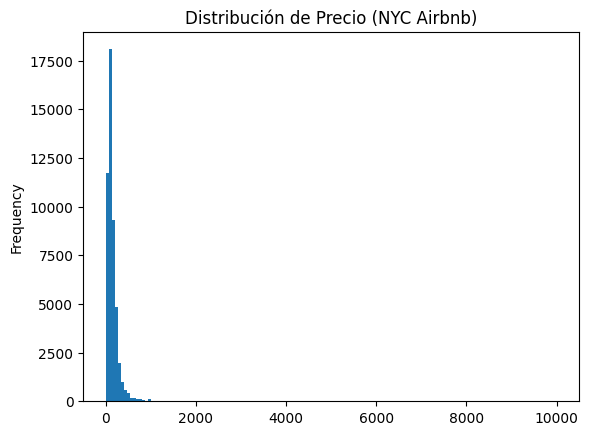

In [43]:
# 4.1 — Construye un histograma de 'price' con .plot(kind='hist').
# Elige un número de bins que te parezca razonable y comenta por qué lo elegiste.
df['price'].plot(kind='hist', bins=150, title='Distribución de Precio (NYC Airbnb)') #use el numero 150 porque ya es claro la forma que tiene la distribucion de los valores de price pareciendo una normal muy estrecha, debido a las cantidades raras
plt.show()



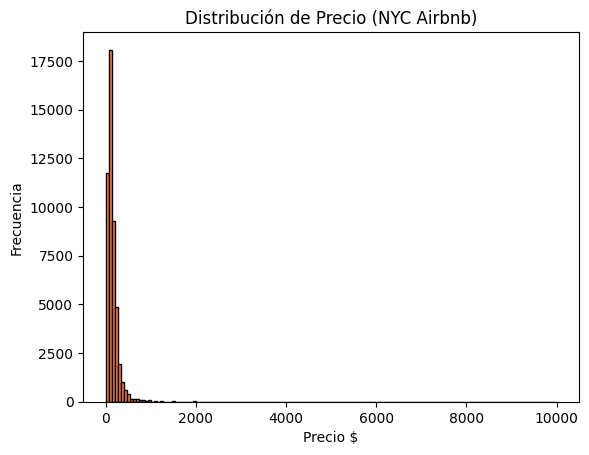

In [44]:
# 4.2 — Construye el mismo histograma con matplotlib.pyplot directamente (plt.hist()),
# agregando título y etiquetas en los ejes.
plt.hist(df['price'], bins=150, color='coral', edgecolor='black')
plt.title('Distribución de Precio (NYC Airbnb)')
plt.xlabel('Precio $')
plt.ylabel('Frecuencia')
plt.show()



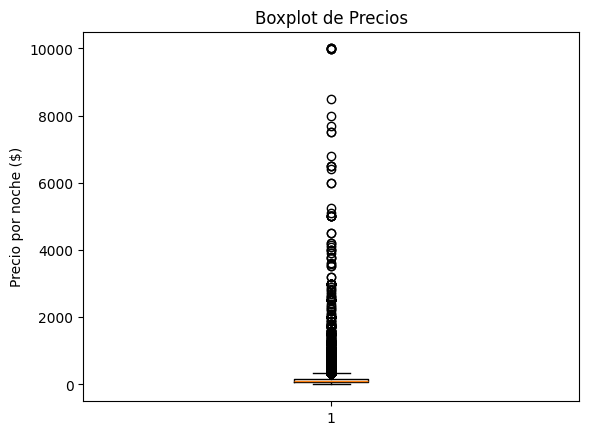

In [45]:
# 4.3 — Construye un boxplot de 'price' (con .plot(kind='box') o plt.boxplot()).
plt.boxplot(df['price'].dropna())
plt.title('Boxplot de Precios')
plt.ylabel('Precio por noche ($)')
plt.show()



**4.4 — Conclusión (responde aquí en Markdown):**

Describe lo que observas en el histograma y el boxplot de `price`. ¿Los outliers son visibles en ambos gráficos? ¿En cuál se distinguen mejor? Relaciona tu respuesta con los valores de asimetría y curtosis que calculaste en la Actividad 3.

_Tu respuesta:_

En el histograma, los datos estan muy acumulados cerca del 0 y como tiene valores inconsistentes que se alejan mucho del resto de los numeros, hace que el histograma se vea muy estrecho, esto genera que los outliers sean casi inperseptibles. Mientras que en el boxplot, los outlier reasaltan mucho en la grafica, haciendo que la caja y sus limites se vea muy aplastada, reflejando asi de una manera clara la gran asimetría positiva y curtosis calculadas en la actividad 3.

---
## Reflexión final (10 pts)

Con base en las 4 actividades anteriores: si tuvieras que explicarle a alguien que no ha visto este dataset por qué el precio "promedio" de $152.72 puede ser engañoso, ¿qué le dirías, usando al menos dos de las medidas que calculaste?

_Tu respuesta:_

Le diria que el promedio es muy engañoso ya que el dataset tiene muchos valores  atipicos, lo cual infla mucho la media, le diria que para viera mejor al rango intercuantil para que se diera cuenta de como estan distribuidos los datos del centro y como este dista bastante del promedio. Ademas de que viera las gran desviacion estandar, la cual al ser tan grande nos dice que existe una gran dispersion de los datos.


---
## Rúbrica de evaluación

| Actividad | Puntos | Criterio |
|---|---|---|
| 1. Tendencia central | 20 | Calcula correctamente media, mediana, moda; la conclusión (1.2) conecta la divergencia con la presencia de outliers, no es una afirmación aislada |
| 2. Dispersión | 20 | Calcula correctamente rango, varianza, std, IQR; la conclusión (2.2) justifica cuál medida es más representativa con evidencia del propio cálculo |
| 3. Forma | 20 | Calcula correctamente asimetría y curtosis; la conclusión (3.2) compara explícitamente contra el caso de `Income` visto en clase |
| 4. Visualización | 30 | Histograma y boxplot correctamente construidos (ambas versiones: `.plot()` y `plt.`); código comentado justificando decisiones (ej. bins); la conclusión (4.4) conecta lo visual con los estadísticos de la Actividad 3 |
| Reflexión final | 10 | La explicación usa al menos dos medidas concretas, no es una respuesta genérica |
| **Total** | **100** | |